# Faster R-CNN — Fine-Tuning on CityPersons
> **Note:** Run the Preprocessing notebook first to make sure `train_loader` and `val_loader` are working correctly before running this one.

## 1. Imports

In [1]:
import os
import glob
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Check if GPU is available via Cuda or MPS (Mac)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Dataset and DataLoaders

Copy the same Dataset class and DataLoaders from the Preprocessing notebook.

In [3]:
DATA_ROOT = r"C:\Users\tsega\Documents\AI with ML\Image Processing & Comp Vision\Final Project\CityPersons\Citypersons"

def yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h):
    x_min = (x_c - w / 2) * img_w
    y_min = (y_c - h / 2) * img_h
    x_max = (x_c + w / 2) * img_w
    y_max = (y_c + h / 2) * img_h
    return [x_min, y_min, x_max, y_max]


def read_labels(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if int(parts[0]) == 0:  # 0 = pedestrian
                box = yolo_to_xyxy(float(parts[1]), float(parts[2]),
                                   float(parts[3]), float(parts[4]),
                                   img_w, img_h)
                boxes.append(box)
    return boxes


class CityPersonsDataset(Dataset):

    def __init__(self, data_root, split):
        self.split     = split
        self.img_dir   = os.path.join(data_root, 'images', split)
        self.label_dir = os.path.join(data_root, 'labels', split)
        self.images    = sorted(glob.glob(os.path.join(self.img_dir, '**', '*.png'), recursive=True))
        print(f"[{split}] {len(self.images)} images found")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path   = self.images[idx]
        label_path = img_path.replace(
            os.path.join('images', self.split),
            os.path.join('labels', self.split)
        ).replace('.png', '.txt')

        img      = cv2.imread(img_path)
        img      = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]

        boxes = read_labels(label_path, img_w, img_h)

        if len(boxes) > 0:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.ones(len(boxes), dtype=torch.int64)
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros(0, dtype=torch.int64)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "image_id": torch.tensor([idx]),
            "area":     (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.zeros(0),
            "iscrowd":  torch.zeros(len(boxes), dtype=torch.int64)
        }

        return F.to_tensor(img), target

In [4]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = CityPersonsDataset(DATA_ROOT, split='train')
val_dataset   = CityPersonsDataset(DATA_ROOT, split='val')

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

[train] 2975 images found
[val] 502 images found
Training batches:   1488
Validation batches: 251


## 3. Load the Pre-trained Faster R-CNN Model

Load Faster R-CNN pre-trained on COCO and replace the final prediction head to detect only **2 classes**: background and pedestrian.

```
Original model (COCO):          Our model (CityPersons):
  ...                              ...
  └── Head (91 classes)    →       └── Head (2 classes)
                                        0 = background
                                        1 = pedestrian
```

In [5]:
# Load pre-trained model
model = fasterrcnn_resnet50_fpn(pretrained=True)

# Replace the head for 2 classes (background + pedestrian)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(device)
print("Model ready.")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

c:\Users\tsega\anaconda3\envs\midterm\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\tsega\anaconda3\envs\midterm\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model ready.
Total parameters: 41,299,161


## 4. Optimizer

In [6]:
# Only train parameters that require gradients
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# Reduce learning rate by 10x after 3 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Optimizer ready.")

Optimizer ready.


## 5. Training Loop

In [7]:
NUM_EPOCHS = 5

train_losses = []
val_losses   = []

for epoch in range(NUM_EPOCHS):

    # --- Training ---
    model.train()
    epoch_loss = 0

    for i, (images, targets) in enumerate(train_loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)   # forward pass
        loss      = sum(loss_dict.values())  # sum all losses

        optimizer.zero_grad()
        loss.backward()                      # backpropagation
        optimizer.step()                     # update weights

        epoch_loss += loss.item()

        if i % 100 == 0:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.train()  # Faster R-CNN needs train mode to compute val loss
    epoch_val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            epoch_val_loss += sum(loss_dict.values()).item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    lr_scheduler.step()

    print(f"\n=== Epoch {epoch+1} Summary ===")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}\n")

Epoch 1/5 | Batch 0/1488 | Loss: 1.1041
Epoch 1/5 | Batch 100/1488 | Loss: 0.2409
Epoch 1/5 | Batch 200/1488 | Loss: 0.1309
Epoch 1/5 | Batch 300/1488 | Loss: 0.1280
Epoch 1/5 | Batch 400/1488 | Loss: 0.3827
Epoch 1/5 | Batch 500/1488 | Loss: 0.0185
Epoch 1/5 | Batch 600/1488 | Loss: 0.1250
Epoch 1/5 | Batch 700/1488 | Loss: 0.3950
Epoch 1/5 | Batch 800/1488 | Loss: 2.1602
Epoch 1/5 | Batch 900/1488 | Loss: 0.6514
Epoch 1/5 | Batch 1000/1488 | Loss: 0.5790
Epoch 1/5 | Batch 1100/1488 | Loss: 0.3589
Epoch 1/5 | Batch 1200/1488 | Loss: 0.3500
Epoch 1/5 | Batch 1300/1488 | Loss: 0.0323
Epoch 1/5 | Batch 1400/1488 | Loss: 0.2808

=== Epoch 1 Summary ===
Train Loss: 0.4766
Val Loss:   0.5317

Epoch 2/5 | Batch 0/1488 | Loss: 0.7422
Epoch 2/5 | Batch 100/1488 | Loss: 0.1553
Epoch 2/5 | Batch 200/1488 | Loss: 0.8033
Epoch 2/5 | Batch 300/1488 | Loss: 0.5313
Epoch 2/5 | Batch 400/1488 | Loss: 0.8713
Epoch 2/5 | Batch 500/1488 | Loss: 0.2943
Epoch 2/5 | Batch 600/1488 | Loss: 0.7319
Epoch 2/5 |

## 6. Plot Training and Validation Loss

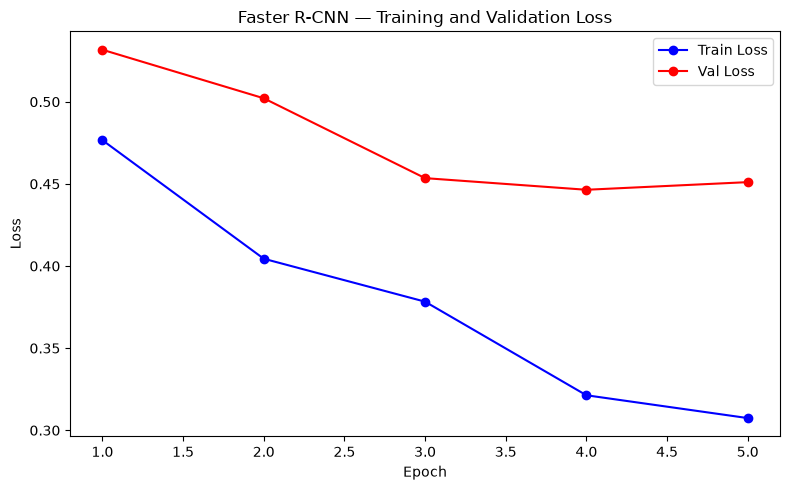

Loss curve saved as loss_curve.png


In [8]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
plt.plot(epochs, val_losses,   'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN — Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png')
plt.show()
print("Loss curve saved as loss_curve.png")

## 7. Save the Trained Model

In [9]:
torch.save(model.state_dict(), 'fasterrcnn_citypersons.pth')
print("Model saved as fasterrcnn_citypersons.pth")

Model saved as fasterrcnn_citypersons.pth


## 8. Run Inference on Validation Images

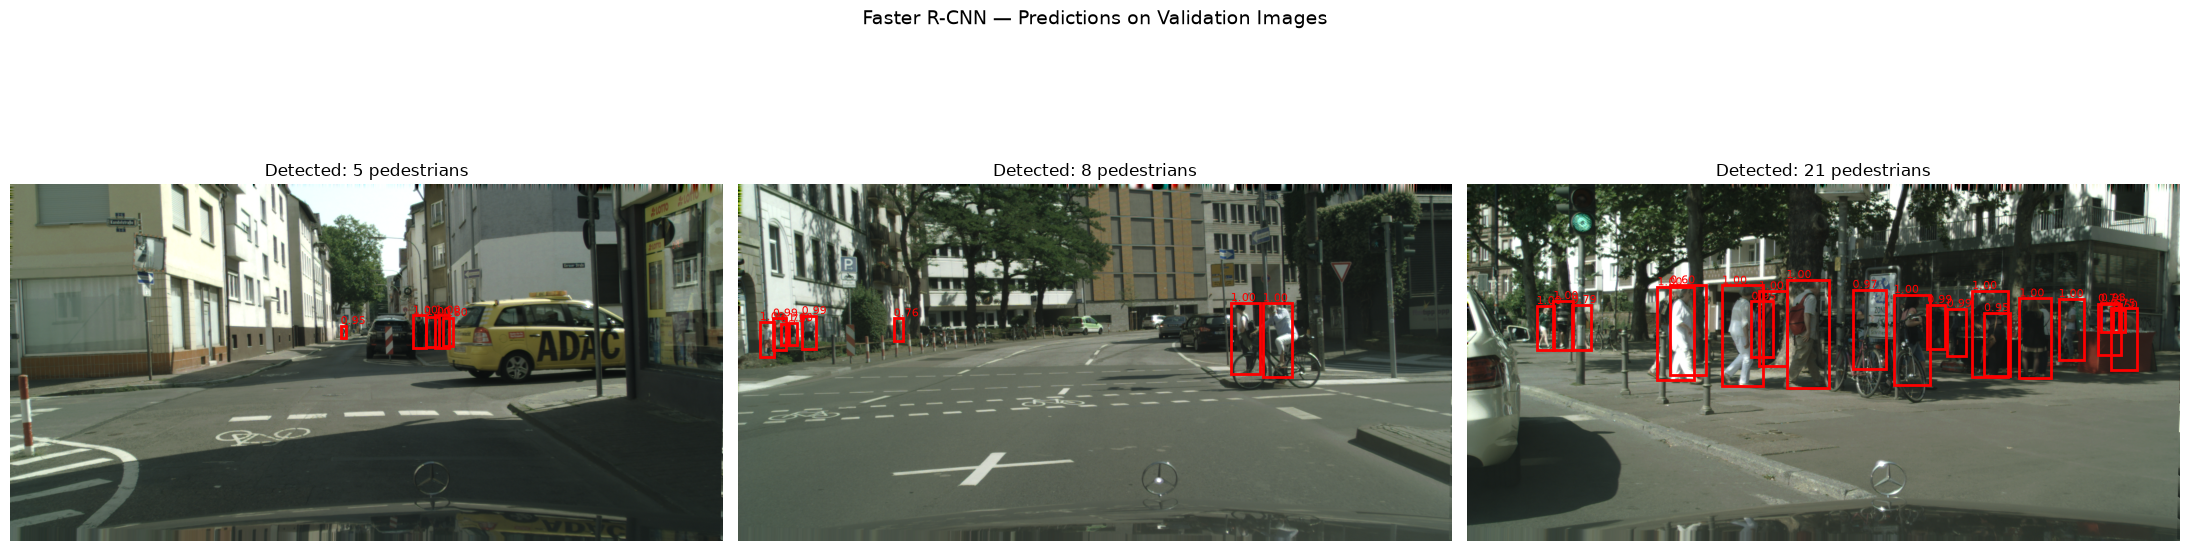

Predictions saved as predictions.png


In [10]:
SCORE_THRESHOLD = 0.5  # Only show boxes with confidence >= 50%

model.eval()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, ax in enumerate(axes):
    img_tensor, target = val_dataset[i * 50]

    with torch.no_grad():
        prediction = model([img_tensor.to(device)])[0]

    # Convert tensor back to numpy for display
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    ax.imshow(img_np)

    # Draw predicted boxes
    for box, score in zip(prediction['boxes'].cpu(), prediction['scores'].cpu()):
        if score >= SCORE_THRESHOLD:
            x_min, y_min, x_max, y_max = box.tolist()
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x_min, y_min - 5, f"{score:.2f}", color='red', fontsize=8)

    detected = sum(1 for s in prediction['scores'].cpu() if s >= SCORE_THRESHOLD)
    ax.set_title(f"Detected: {detected} pedestrians")
    ax.axis('off')

plt.suptitle("Faster R-CNN — Predictions on Validation Images", fontsize=14)
plt.tight_layout()
plt.savefig('predictions.png')
plt.show()
print("Predictions saved as predictions.png")

## 9. Evaluation Metrics — mAP, Precision, Recall

Loss alone does not tell us how well the model detects pedestrians in practice.
We use **mAP (mean Average Precision)** — the standard metric for object detection.

- **mAP@0.5** — a predicted box is correct if it overlaps the real box by at least 50% (IoU ≥ 0.5)
- **mAP@0.5:0.95** — stricter version, averages mAP from IoU 0.5 to 0.95 (COCO standard)
- **Precision** — of all boxes the model predicted, how many were correct?
- **Recall** — of all real pedestrians, how many did the model find?

In [ ]:
# Install torchmetrics if needed
#!pip install torchmetrics -q
#!pip install torchmetrics pycocotools -q
#!pip install torchmetrics faster-coco-eval -q


In [7]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = fasterrcnn_resnet50_fpn(pretrained=False)
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.load_state_dict(torch.load('fasterrcnn_citypersons.pth', map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully.")


c:\Users\tsega\anaconda3\envs\midterm\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\tsega/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s] 
C:\Users\tsega\AppData\Local\Temp\ipykernel_43952\2353412540.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. Th

Model loaded successfully.


In [8]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

metric = MeanAveragePrecision(iou_type="bbox")

model.eval()
with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        preds  = model(images)

        # Convert to CPU and format for torchmetrics
        preds_fmt = [
            {"boxes": p["boxes"].cpu(), "scores": p["scores"].cpu(), "labels": p["labels"].cpu()}
            for p in preds
        ]
        targets_fmt = [
            {"boxes": t["boxes"].cpu(), "labels": t["labels"].cpu()}
            for t in targets
        ]

        metric.update(preds_fmt, targets_fmt)

results = metric.compute()

print("=== Evaluation Results ===")
print(f"mAP@0.5:       {results['map_50']:.4f}")
print(f"mAP@0.5:0.95:  {results['map']:.4f}")
print(f"Precision:     {results['map_per_class']}")  # per class
print(f"Recall:        {results['mar_100']}")

=== Evaluation Results ===
mAP@0.5:       0.6835
mAP@0.5:0.95:  0.4101
Precision:     -1.0
Recall:        0.4857828915119171


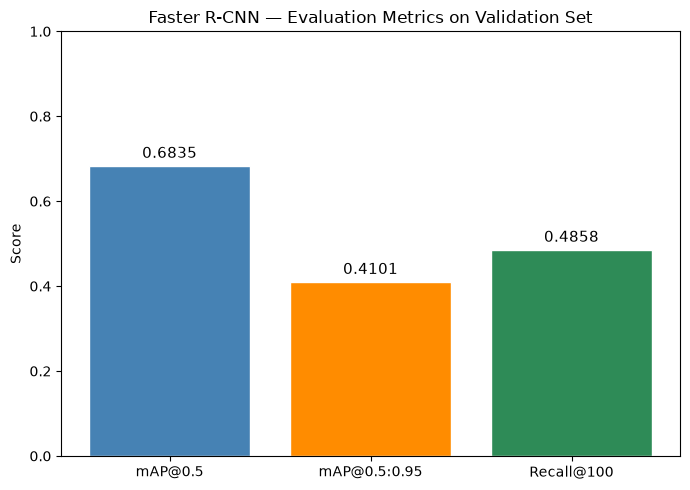

Metrics chart saved as metrics.png


In [9]:
# Bar chart of the main metrics
metric_names  = ['mAP@0.5', 'mAP@0.5:0.95', 'Recall@100']
metric_values = [
    results['map_50'].item(),
    results['map'].item(),
    results['mar_100'].item()
]

plt.figure(figsize=(7, 5))
bars = plt.bar(metric_names, metric_values, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')

# Add value labels on top of each bar
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.4f}", ha='center', va='bottom', fontsize=11)

plt.ylim(0, 1.0)
plt.ylabel('Score')
plt.title('Faster R-CNN — Evaluation Metrics on Validation Set')
plt.tight_layout()
plt.savefig('metrics.png')
plt.show()
print("Metrics chart saved as metrics.png")